In [1]:
import pandas as pd
import numpy as np
import random
from deap import base, creator, tools, algorithms
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

In [51]:
# load the processed dataset

df = pd.read_excel('./processed_data/fully_noise_imputed_data.xlsx')
df.set_index('Year', inplace=True)

# define target variable and features
y = df['pollinators_mean_occupancy'].values


X_df = df.drop(columns=[
    'pollinators_mean_occupancy', 
])

X = X_df.values
feature_names = X_df.columns.tolist()
NUM_FEATURES = len(feature_names)

In [52]:
X_df.columns[13:]

Index(['plant_abundance_arable_unsmoothed_index',
       'plant_abundance_bog_and_heath_unsmoothed_index',
       'plant_abundance_grassland_unsmoothed_index',
       'plant_abundance_woodland_unsmoothed_index'],
      dtype='str')

In [67]:
# setup the genetic algorithm using DEAP

# minimize the negative mean cross-validated R^2 score
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# define chromosomes as a list of binary valies
toolbox = base.Toolbox()

# randomly assign values to each gene
toolbox.register("attr_bool", random.randint, 0, 1)

# create an individual and a population of individuals
def create_individual():
    # let GA optimise the start and end years 
    start_year = 1980 #random.randint(1980, 2020)
    end_year = 2024#random.randint(2000, 2024)

    if start_year >= end_year:
        start_year, end_year = end_year - 1, start_year + 1
    
    # features = [random.randint(0, 1) for _ in range(NUM_FEATURES)]
    features = [1 for _ in range(NUM_FEATURES)] # start with all features included, and let the GA remove them if they are not useful
    return creator.Individual([start_year, end_year] + features)

toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [68]:
# At this point, individuals look like this: 
# [start_year, end_year, feature1_included, feature2_included, ..., featureN_included]


In [ ]:
# create evaluation function for finding the best feature subset

def evaluate_feature_subset(individual):
    start_year, end_year = individual[0], individual[1]
    feature_flags = individual[2:]

    # decode the chromosome to get selected feature indices
    selected_features = [feature_names[i] for i in range(NUM_FEATURES) if feature_flags[i] == 1]

    # penalty if the GA tries to drop ALL features (invalid model)
    if len(selected_features) == 0:
        return (9999.0,) # Return a massive error to kill off this chromosome
    
    # same for invalid years ranges
    if start_year >= end_year:
        print("gaaaah")
        return (9999.0,)
    
    # temporal slice
    mask = (df.index >= start_year) & (df.index <= end_year)
    X_masked = X_df.loc[mask, selected_features]
    y_masked = y[mask]

    if X_masked.isna().any().any() or pd.isna(y_masked).any():
        return (9999.0,)

    # Create SVR model pipeline with feature scaling
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
    ])
    
    # 5 fold cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # get negative mean squared error scores and convert to RMSE
    try:
        scores = cross_val_score(model, X_masked, y_masked, cv=cv, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-scores.mean())
    except:
        return (9999.0,)
    
    # add a small penalty for every feature used.
    penalty_weight = 0.01

    num_years_captured = end_year - start_year
    
    fitness_score = rmse - (0.1 * num_years_captured)# + (penalty_weight * len(selected_indices))

    
    return (fitness_score,)

# Register the evaluation function
toolbox.register("evaluate", evaluate_feature_subset)

In [70]:
# need a custom mutation function to ensure valid year ranges
def custom_mutate(individual, indpb):
    # 30% chance to mutate the years
    if random.random() < indpb:
        individual[0] = random.randint(1980, 2023)
    if random.random() < indpb:
        individual[1] = random.randint(1980, 2024)
        
    if individual[0] >= individual[1]:
        individual[0], individual[1] = individual[1] - 1, individual[0] + 1
        # ensure we didn't push end_year past 2024
        individual[1] = min(individual[1], 2024)
        
    # mutate features normally
    for i in range(2, len(individual)):
        if random.random() < indpb:
            individual[i] = type(individual[i])(not individual[i])
    return individual,

In [71]:
# uniform crossover 50% chance of swapping each gene
toolbox.register("mate", tools.cxUniform, indpb=0.5)

toolbox.register("mutate", custom_mutate, indpb=0.2)

# picks the best randomly chosen individuals
toolbox.register("select", tools.selTournament, tournsize=3)

In [72]:

print("Initializing Genetic Algorithm")

# create initial population
pop = toolbox.population(n=50)

# HOF keeps track of the absolute best individual across all generations
hof = tools.HallOfFame(1)

# # stats to print to console during the run
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)

pop, log = algorithms.eaSimple(pop, 
                                toolbox, 
                                cxpb=0.5, 
                                mutpb=0.2, 
                                ngen=50,
                                stats=stats, 
                                halloffame=hof, 
                                verbose=True)

# results
best_ind = hof[0]
print("\n" + "="*40)
print("OPTIMIZATION COMPLETE")
print("="*40)
print(f"Best Fitness Score (RMSE + Penalty): {best_ind.fitness.values[0]:.4f}")

print("\nOptimized Feature Subset:")
selected_features = []
for i in range(NUM_FEATURES):
    if best_ind[i] == 1:
        selected_features.append(feature_names[i])
        print(f"  [X] {feature_names[i]}")
    else:
        print(f"  [ ] {feature_names[i]}")
        
print(f"\nTotal Features Kept: {len(selected_features)} out of {NUM_FEATURES}")
print(f"Dimensionality Reduction: {100 - (len(selected_features)/NUM_FEATURES)*100:.1f}%")
    

Initializing Genetic Algorithm
gen	nevals	avg    	min    
0  	50    	2.91263	2.91263
1  	30    	2.95595	0.928179
2  	28    	202.593	0.490242
3  	32    	2.4077 	0.490242
4  	21    	2.04976	0.485228
5  	28    	1.04119	0.368512
6  	37    	201.009	0.262102
7  	34    	0.613186	0.262102
8  	40    	200.46  	0.155716
9  	28    	0.413169	0.0701141
10 	28    	0.338917	0.0701141
11 	30    	0.257199	0.0701141
12 	30    	0.174479	0.0109395
13 	24    	0.187894	0.0109395
14 	30    	200.199 	0.0109395
15 	37    	200.278 	0.00917433
16 	29    	0.126529	0.00917433
17 	34    	200.156 	0.00917433
18 	37    	0.163027	0.00917433
19 	31    	200.11  	0.00917433
20 	34    	200.135 	0.00917433
21 	32    	200.102 	0.000976281
22 	23    	0.175313	0.000976281
23 	36    	200.209 	-0.0125428 
24 	27    	400.171 	-0.0125428 
25 	25    	200.081 	-0.0125428 
26 	32    	0.222416	-0.0125428 
27 	34    	200.359 	-0.0125428 
28 	41    	0.211871	-0.0125428 
29 	32    	0.15027 	-0.122279  
30 	19    	200.04  	-0.0674383 
31 

In [73]:
best_ind



[1980, 2008, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0]

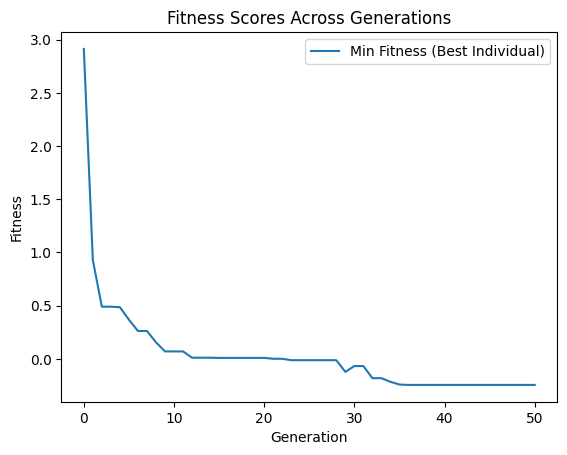

<Figure size 640x480 with 0 Axes>

In [ ]:
# graph of fitness scores across generations
min = log.select("min")
avg = log.select("avg")
import seaborn as sns
import matplotlib.pyplot as plt

# sns.lineplot(x=range(len(min)), y=min, label="Min Fitness (Best Individual)")
# sns.lineplot(x=range(len(avg)), y=avg, label="Average Fitness")
plt.plot(min, label="Min Fitness (Best Individual)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Fitness Scores Across Generations")
plt.legend()
plt.show()

plt.savefig("figures/fitness_over_generations.png")

In [87]:
#baseline model with all features and full timeline

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

# 5-Fold Cross Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = cross_val_score(baseline_model, X, y, cv=cv, scoring='neg_mean_squared_error')
baseline_rmse = np.sqrt(-baseline_scores.mean())

print(f"Total Features Used: {NUM_FEATURES}")
print(f"Baseline Cross-Validated RMSE: {baseline_rmse:.4f}")

Total Features Used: 17
Baseline Cross-Validated RMSE: 7.3126
